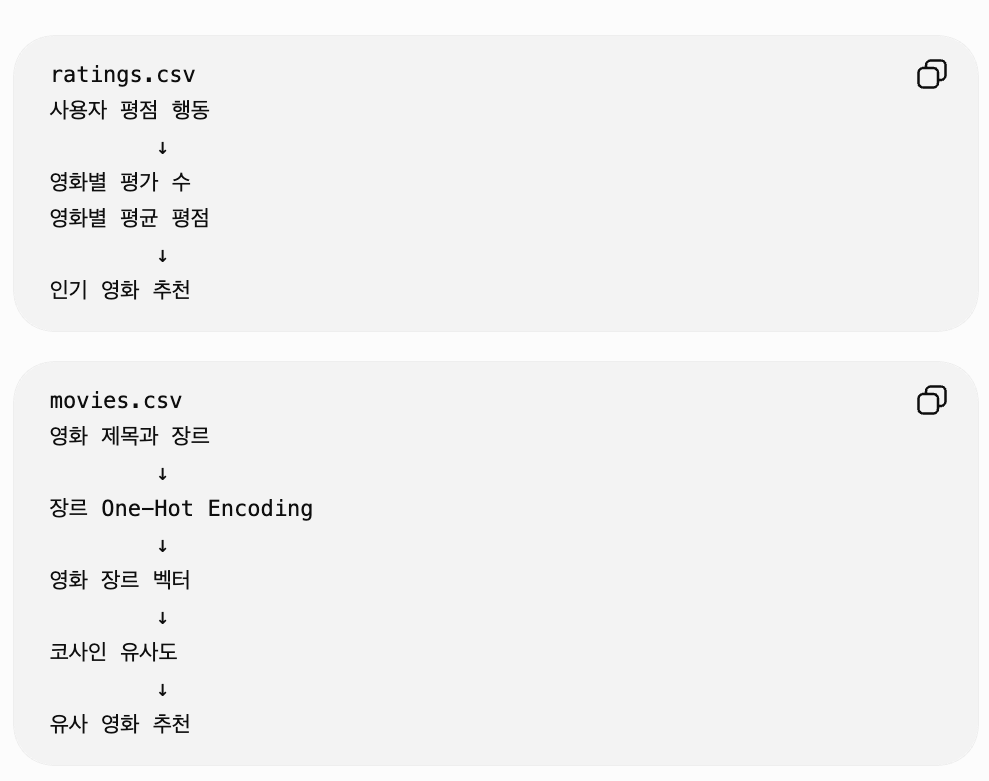

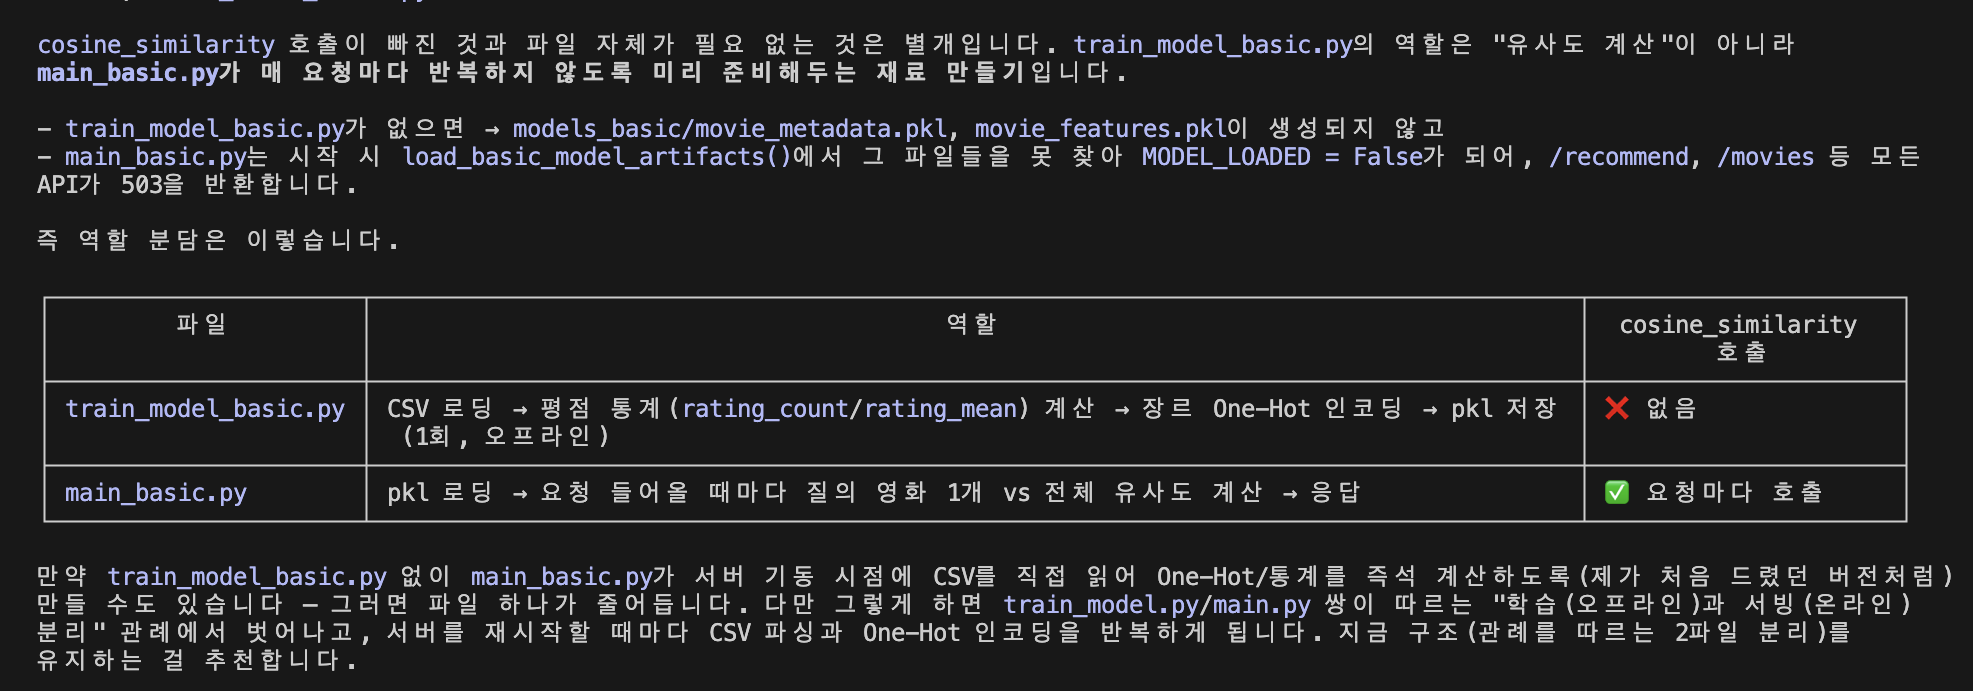

## 1. 라이브러리 불러오기

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. 데이터 로딩

In [ ]:
ratings = pd.read_csv("../data/ratings.csv")
movies = pd.read_csv("../data/movies.csv")

print(ratings.head())
print(movies.head())

## 3. 데이터 구조 확인

In [5]:
print(ratings.shape)
print(movies.shape)

(100836, 4)
(9742, 3)


In [6]:
print(ratings.columns)
print(movies.columns)

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
Index(['movieId', 'title', 'genres'], dtype='object')


## 4. 결측치와 중복 확인

In [7]:
print(ratings.isnull().sum())
print(movies.isnull().sum())

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
movieId    0
title      0
genres     0
dtype: int64


In [8]:
print(ratings.duplicated().sum())
print(movies.duplicated().sum())

0
0


In [10]:
# 동일한 사용자가 동일한 영화에 대해 두번 평점을 주었는지 중복 확인
print(ratings.duplicated(subset=["userId", "movieId"]).sum())

0


## 5. ratings + movies 병합

In [17]:
movie_ratings = ratings.merge(movies, on="movieId", how="left")
print(movie_ratings.head())
print(ratings.shape, movie_ratings.shape)

   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  
(100836, 4) (100836, 6)


## 6. 전체 평점 분포

In [21]:
rating_counts = ratings["rating"].value_counts().sort_index()
print(rating_counts)

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


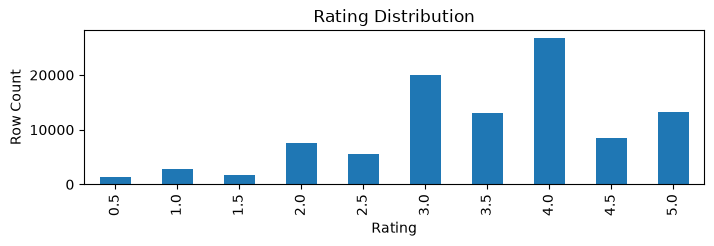

In [25]:
rating_counts.plot(kind="bar", figsize=(8,2))
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Row Count")
plt.show()

## 7. 사용자별 평점 개수

In [36]:
user_rating_count = (ratings.groupby("userId").size().reset_index(name="user_rating_count"))
print(user_rating_count.head())

   userId  user_rating_count
0       1                232
1       2                 29
2       3                 39
3       4                216
4       5                 44


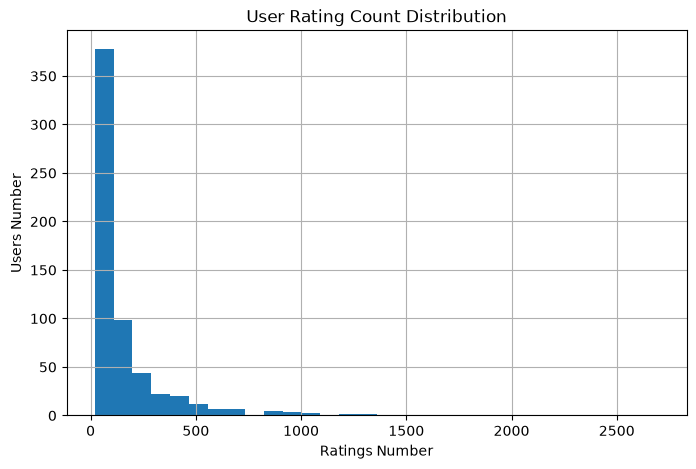

In [39]:
user_rating_count["user_rating_count"].hist(bins=30, figsize=(8,5))
plt.title("User Rating Count Distribution")
plt.xlabel("Ratings Number")
plt.ylabel("Users Number")
plt.show()

## 8. 영화별 평점 개수 Feature 생성

In [46]:
movie_rating_count = (ratings.groupby("movieId").size().reset_index(name="movie_rating_count"))
print(movie_rating_count.head())

   movieId  movie_rating_count
0        1                 215
1        2                 110
2        3                  52
3        4                   7
4        5                  49


In [47]:
movie_rating_count = movie_rating_count.merge(movies, on="movieId")
print(movie_rating_count.head())

   movieId  movie_rating_count                               title  \
0        1                 215                    Toy Story (1995)   
1        2                 110                      Jumanji (1995)   
2        3                  52             Grumpier Old Men (1995)   
3        4                   7            Waiting to Exhale (1995)   
4        5                  49  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [48]:
## 🔥 평가수가 많다는?? 영화부터 확인
popular_movies = movie_rating_count.sort_values("movie_rating_count", ascending=False)
print(popular_movies.head())

      movieId  movie_rating_count                             title  \
314       356                 329               Forrest Gump (1994)   
277       318                 317  Shawshank Redemption, The (1994)   
257       296                 307               Pulp Fiction (1994)   
510       593                 279  Silence of the Lambs, The (1991)   
1938     2571                 278                Matrix, The (1999)   

                           genres  
314      Comedy|Drama|Romance|War  
277                   Crime|Drama  
257   Comedy|Crime|Drama|Thriller  
510         Crime|Horror|Thriller  
1938       Action|Sci-Fi|Thriller  


## 9. 영화별 평균 평점 Feature 생성

In [50]:
movie_rating_mean = (ratings.groupby("movieId")["rating"]
                        .mean()
                        .reset_index(name="movie_rating_mean")
                    )
print(movie_rating_mean.head())

   movieId  movie_rating_mean
0        1           3.920930
1        2           3.431818
2        3           3.259615
3        4           2.357143
4        5           3.071429


In [51]:
# 평점 갯수 + 평점 평균 합치기
movie_stats = movie_rating_count.merge(movie_rating_mean, on="movieId")
print(movie_stats.head())

   movieId  movie_rating_count                               title  \
0        1                 215                    Toy Story (1995)   
1        2                 110                      Jumanji (1995)   
2        3                  52             Grumpier Old Men (1995)   
3        4                   7            Waiting to Exhale (1995)   
4        5                  49  Father of the Bride Part II (1995)   

                                        genres  movie_rating_mean  
0  Adventure|Animation|Children|Comedy|Fantasy           3.920930  
1                   Adventure|Children|Fantasy           3.431818  
2                               Comedy|Romance           3.259615  
3                         Comedy|Drama|Romance           2.357143  
4                                       Comedy           3.071429  


In [66]:
# 평점이 높은 영화부터 정렬
high_rating_movies = movie_stats.sort_values("movie_rating_mean", ascending=False)
print(high_rating_movies.head())

      movieId  movie_rating_count                                  title  \
7638    88448                   1  Paper Birds (Pájaros de papel) (2010)   
8089   100556                   1             Act of Killing, The (2012)   
9065   143031                   1                        Jump In! (2007)   
9076   143511                   1                           Human (2015)   
9078   143559                   1                    L.A. Slasher (2015)   

                    genres  movie_rating_mean  
7638          Comedy|Drama                5.0  
8089           Documentary                5.0  
9065  Comedy|Drama|Romance                5.0  
9076           Documentary                5.0  
9078  Comedy|Crime|Fantasy                5.0  


## 10. 최소 평점 수 적용

In [67]:
# 영화별 평가 수 분포 확인
print(movie_stats["movie_rating_count"].describe())

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: movie_rating_count, dtype: float64


In [70]:
#(1) 평가수 >= 30 값은 임의로 정함
qualified_movies = movie_stats[movie_stats["movie_rating_count"] >= 30]

print(qualified_movies.head())

   movieId  movie_rating_count                               title  \
0        1                 215                    Toy Story (1995)   
1        2                 110                      Jumanji (1995)   
2        3                  52             Grumpier Old Men (1995)   
4        5                  49  Father of the Bride Part II (1995)   
5        6                 102                         Heat (1995)   

                                        genres  movie_rating_mean  
0  Adventure|Animation|Children|Comedy|Fantasy           3.920930  
1                   Adventure|Children|Fantasy           3.431818  
2                               Comedy|Romance           3.259615  
4                                       Comedy           3.071429  
5                        Action|Crime|Thriller           3.946078  


In [75]:
#(2) 상위 25% 분위수로 값을 정한다면
# min_rating_count = movie_stats["movie_rating_count"].quantile(0.75)
# qualified_movies = movie_stats[movie_stats["movie_rating_count"] >= min_rating_count]

# print(qualified_movies.head())

   movieId  movie_rating_count                               title  \
0        1                 215                    Toy Story (1995)   
1        2                 110                      Jumanji (1995)   
2        3                  52             Grumpier Old Men (1995)   
4        5                  49  Father of the Bride Part II (1995)   
5        6                 102                         Heat (1995)   

                                        genres  movie_rating_mean  
0  Adventure|Animation|Children|Comedy|Fantasy           3.920930  
1                   Adventure|Children|Fantasy           3.431818  
2                               Comedy|Romance           3.259615  
4                                       Comedy           3.071429  
5                        Action|Crime|Thriller           3.946078  


## 11. 가장 기본적인 인기 영화 추천 함수

In [76]:
def recommend_popular_movies(top_n=10):
    result = (
            qualified_movies.sort_values("movie_rating_mean", ascending=False
        ).head(top_n)
    )

    return result[
        [
            "movieId",
            "title",
            "movie_rating_count",
            "movie_rating_mean"
        ]
    ]
    

In [78]:
recommend_popular_movies(10)

,movieId,title,movie_rating_count,movie_rating_mean
796,1041,Secrets & Lies (1996),11,4.590909
2579,3451,Guess Who's Coming to Dinner (1967),11,4.545455
882,1178,Paths of Glory (1957),12,4.541667
840,1104,"Streetcar Named Desire, A (1951)",20,4.475000
1761,2360,"Celebration, The (Festen) (1998)",12,4.458333
917,1217,Ran (1985),15,4.433333
277,318,"Shawshank Redemption, The (1994)",317,4.429022
731,951,His Girl Friday (1940),14,4.392857
3639,5008,Witness for the Prosecution (1957),9,4.388889
1406,1927,All Quiet on the Western Front (1930),10,4.350000


## 12. 장르 데이터 이해

In [79]:
print(movies[["title", "genres"]].head(10))

                                title  \
0                    Toy Story (1995)   
1                      Jumanji (1995)   
2             Grumpier Old Men (1995)   
3            Waiting to Exhale (1995)   
4  Father of the Bride Part II (1995)   
5                         Heat (1995)   
6                      Sabrina (1995)   
7                 Tom and Huck (1995)   
8                 Sudden Death (1995)   
9                    GoldenEye (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
5                        Action|Crime|Thriller  
6                               Comedy|Romance  
7                           Adventure|Children  
8                                       Action  
9                    Action|Adventure|Thriller  


## 13. 장르 One-Hot Encoding

In [80]:
# str.get_dummies()
genre_features = movies["genres"].str.get_dummies(sep="|")

print(genre_features.head())

   (no genres listed)  Action  Adventure  Animation  Children  Comedy  Crime  \
0                   0       0          1          1         1       1      0   
1                   0       0          1          0         1       0      0   
2                   0       0          0          0         0       1      0   
3                   0       0          0          0         0       1      0   
4                   0       0          0          0         0       1      0   

   Documentary  Drama  Fantasy  Film-Noir  Horror  IMAX  Musical  Mystery  \
0            0      0        1          0       0     0        0        0   
1            0      0        1          0       0     0        0        0   
2            0      0        0          0       0     0        0        0   
3            0      1        0          0       0     0        0        0   
4            0      0        0          0       0     0        0        0   

   Romance  Sci-Fi  Thriller  War  Western  
0        0 

In [82]:
# 영화 정보 + 장르(인코딩)
movie_features = pd.concat(
    [
        movies[["movieId", "title", "genres"]],
        genre_features
    ], 
   axis=1
)

print(movie_features.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  (no genres listed)  Action  \
0  Adventure|Animation|Children|Comedy|Fantasy                   0       0   
1                   Adventure|Children|Fantasy                   0       0   
2                               Comedy|Romance                   0       0   
3                         Comedy|Drama|Romance                   0       0   
4                                       Comedy                   0       0   

   Adventure  Animation  Children  Comedy  Crime  ...  Film-Noir  Horror  \
0          1          1         1       1      0  ...          0       0   
1          1          0         1       0      0  ...          0       0   
2 

## 14. 코사인 유사도 불러오기

유사도 행렬(Similarity Matrix) :: 친구 찾기 표본
- 사용자와 사용자 또는 영화와 영화가 얼마나 비슷한지를 숫자로 나타낸 표(행렬)이다.
- 비슷할수록 -> 1에 가까움
- 다를수록 -> 0에 가까움
- 반대 성향 -> -1에 가까움(일부 유사도)

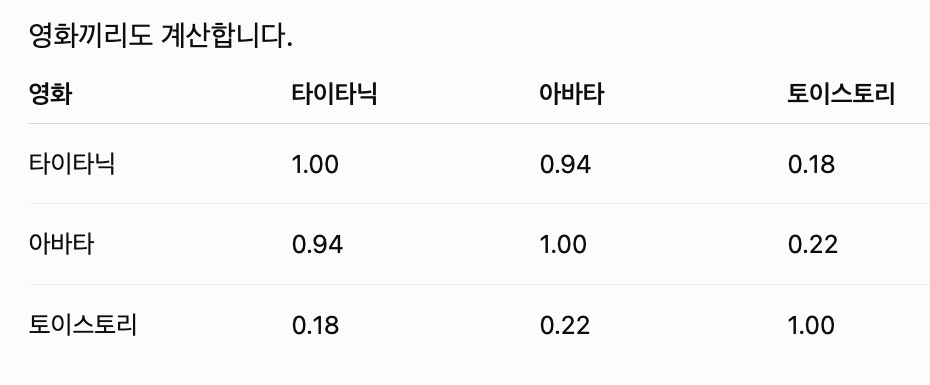

① Cosine Similarity ⭐⭐⭐⭐⭐
가장 많이 사용합니다. 벡터의 각도를 이용해 얼마나 비슷한 방향인지 계산합니다.

② Pearson Correlation ⭐⭐⭐⭐☆
평점의 패턴이 얼마나 비슷한지 계산합니다.

③ Euclidean Distance ⭐⭐⭐
거리를 계산하여 가까울수록 비슷하다고 판단합니다.

In [83]:
# 추천 알고리믖 관련 라이브러리 추가
from sklearn.metrics.pairwise import cosine_similarity

In [85]:
genre_columns = genre_features.columns

print(genre_columns)

Index(['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
       'War', 'Western'],
      dtype='object')


In [87]:
# 영화 간 유사도 계산하기
similarity_matrix = cosine_similarity(
    movie_features[genre_columns]
)

print(similarity_matrix.shape)
print(similarity_matrix)

(9742, 9742)
[[1.         0.77459667 0.31622777 ... 0.         0.31622777 0.4472136 ]
 [0.77459667 1.         0.         ... 0.         0.         0.        ]
 [0.31622777 0.         1.         ... 0.         0.         0.70710678]
 ...
 [0.         0.         0.         ... 1.         0.         0.        ]
 [0.31622777 0.         0.         ... 0.         1.         0.        ]
 [0.4472136  0.         0.70710678 ... 0.         0.         1.        ]]


In [89]:
similarity_matrix[0][1]

np.float64(0.7745966692414835)

In [95]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=movie_features["title"],
    columns=movie_features["title"]
)

similarity_df.iloc[:5, :5]

title,Toy Story (1995),Jumanji (1995),Grumpier Old Men (1995),Waiting to Exhale (1995),Father of the Bride Part II (1995)
title,,,,,
Toy Story (1995),1.000000,0.774597,0.316228,0.258199,0.447214
Jumanji (1995),0.774597,1.000000,0.000000,0.000000,0.000000
Grumpier Old Men (1995),0.316228,0.000000,1.000000,0.816497,0.707107
Waiting to Exhale (1995),0.258199,0.000000,0.816497,1.000000,0.577350
Father of the Bride Part II (1995),0.447214,0.000000,0.707107,0.577350,1.000000


## 15. 특정 영화 찾기

In [96]:
# 1. 정확한 제목을 확인
movies[
    movies["title"].str.contains(
        "Toy Story",
        case=False,
        na=False
    )
]

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
7355,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX


In [98]:
# 2. 데이터프레임 인덱스 찾기
movie_index = movies[
    movies["title"] == "Toy Story (1995)" 
].index[0]

print(movie_index)

0


In [106]:
# 3. Toy Story와 모든 영화의 유사도를 가져옴
similarity_scores = list(
    enumerate(similarity_matrix[movie_index])
)

In [110]:
# 4. 상위 영화부터 정렬
similarity_scores = sorted(
    similarity_scores,
    key=lambda x: x[1],
    reverse=True
)

In [113]:
# 5. 상위 10개 확인 - 첫 번째는 자기 자신이므로 제외 
scores = similarity_scores[1:11]
print(scores)

[(1706, np.float64(0.9999999999999999)), (2355, np.float64(0.9999999999999999)), (2809, np.float64(0.9999999999999999)), (3000, np.float64(0.9999999999999999)), (3568, np.float64(0.9999999999999999)), (6194, np.float64(0.9999999999999999)), (6486, np.float64(0.9999999999999999)), (6948, np.float64(0.9999999999999999)), (7760, np.float64(0.9999999999999999)), (8219, np.float64(0.9999999999999999))]


In [117]:
# 6. 추천 영화 인덱스 추출
recommended_indexes = [
    index for index, score in scores
]

movies.iloc[recommended_indexes]

,movieId,title,genres
1706,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
2809,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3000,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3568,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
6194,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy
6486,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy
6948,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy
7760,91355,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy
8219,103755,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy


## 16. 콘텐츠 기반 추천 함수

In [120]:
def recommend_similar_movies(title, top_n=10):
    matched_movies = movies[
        movies["title"].str.lower() == title.lower()
    ]

    if matched_movies.empty:
        return pd.DataFrame(
            {"message": ["영화를 찾을 수 없습니다."]}
        )

    movie_index = matched_movies.index[0]

    # 3. 검색한 영화와 모든 영화의 유사도를 가져옴
    similarity_scores = list(
        enumerate(similarity_matrix[movie_index])
    )

    # 4. 상위 영화부터 정렬
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # 5. 상위 10개 확인 - 첫 번째는 자기 자신이므로 제외 
    similarity_scores = similarity_scores[1:top_n +1]

    # 6. 추천 영화 인덱스 추출
    recommended_indexes = [
        index for index, score in similarity_scores
    ]

    recommendations = movies.iloc[
        recommended_indexes
    ][
        ["movieId", "title", "genres"]
    ].copy()

    recommendations["similartity_score"] = [
        score for index, score in similarity_scores
    ]

    return recommendations
    

In [121]:
recommend_similar_movies("Toy Story (1995)", top_n=10)

,movieId,title,genres,similartity_score
1706,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.0
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.0
2809,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3000,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3568,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.0
6194,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,1.0
6486,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,1.0
6948,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,1.0
7760,91355,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,1.0
8219,103755,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy,1.0


In [122]:
recommend_similar_movies(
    "Matrix, The (1999)",
    top_n=10
)

,movieId,title,genres,similartity_score
68,76,Screamers (1995),Action|Sci-Fi|Thriller,1.0
144,172,Johnny Mnemonic (1995),Action|Sci-Fi|Thriller,1.0
296,338,Virtuosity (1995),Action|Sci-Fi|Thriller,1.0
336,379,Timecop (1994),Action|Sci-Fi|Thriller,1.0
474,541,Blade Runner (1982),Action|Sci-Fi|Thriller,1.0
567,692,Solo (1996),Action|Sci-Fi|Thriller,1.0
601,748,"Arrival, The (1996)",Action|Sci-Fi|Thriller,1.0
939,1240,"Terminator, The (1984)",Action|Sci-Fi|Thriller,1.0
1373,1882,Godzilla (1998),Action|Sci-Fi|Thriller,1.0
1939,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,1.0


## 17. 추천 결과에 평점 정보 추가

In [124]:
movie_result_data = movies.merge(
    movie_stats[
        [
            "movieId",
            "movie_rating_count",
            "movie_rating_mean"
        ]
    ],
    on="movieId",
    how="left"
)

print(movie_result_data.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  movie_rating_count  \
0  Adventure|Animation|Children|Comedy|Fantasy               215.0   
1                   Adventure|Children|Fantasy               110.0   
2                               Comedy|Romance                52.0   
3                         Comedy|Drama|Romance                 7.0   
4                                       Comedy                49.0   

   movie_rating_mean  
0           3.920930  
1           3.431818  
2           3.259615  
3           2.357143  
4           3.071429  


In [126]:
# 🔥 추천 함수에서 movie_result_data를 사용하도록 수정!!
def recommend_similar_movies(title, top_n=10):
    matched_movies = movies[
        movies["title"].str.lower()
        == title.lower()
    ]

    if matched_movies.empty:
        return pd.DataFrame(
            {"message": ["영화를 찾을 수 없습니다."]}
        )

    movie_index = matched_movies.index[0]

    similarity_scores = list(
        enumerate(similarity_matrix[movie_index])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # 🔥 수정 시작
    similarity_scores = similarity_scores[1:]

    results = []

    for index, score in similarity_scores:
        movie = movie_result_data.iloc[index]

        if movie["movie_rating_count"] >= 10:
            results.append({
                "movieId": movie["movieId"],
                "title": movie["title"],
                "genres": movie["genres"],
                "similarity_score": round(score, 3),
                "rating_count": int(
                    movie["movie_rating_count"]
                ),
                "rating_mean": round(
                    movie["movie_rating_mean"],
                    2
                )
            })

        if len(results) == top_n:
            break
    # 🔥 수정 종료

    return pd.DataFrame(results)

In [127]:
recommend_similar_movies(
    "Toy Story (1995)",
    top_n=10
)

,movieId,title,genres,similarity_score,rating_count,rating_mean
0,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.000,45,3.24
1,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.000,97,3.86
2,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.000,37,3.72
3,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.000,132,3.87
4,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,1.000,21,3.02
5,166461,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,1.000,10,3.45
6,673,Space Jam (1996),Adventure|Animation|Children|Comedy|Fantasy|Sc...,0.913,53,2.71
7,4306,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...,0.913,170,3.87
8,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.913,55,4.11
9,108932,The Lego Movie (2014),Action|Adventure|Animation|Children|Comedy|Fan...,0.913,31,3.87


In [ ]:
✅ 추천 기준이 두 가지로 늘어남
   1. 장르가 비슷한가?
   2. 일정 수 이상 평가받았는가?

## 18. 추천 이유 추가

In [128]:
def get_common_genres(
    selected_genres,
    recommended_genres
):
    selected_set = set(
        selected_genres.split("|")
    )

    recommended_set = set(
        recommended_genres.split("|")
    )

    common_genres = (
        selected_set & recommended_set
    )

    return ", ".join(sorted(common_genres))

In [130]:
# 🔥 추천 함수에서 추천 이유 추가하도록 수정!!
def recommend_similar_movies(title, top_n=10):
    matched_movies = movies[
        movies["title"].str.lower()
        == title.lower()
    ]

    if matched_movies.empty:
        return pd.DataFrame(
            {"message": ["영화를 찾을 수 없습니다."]}
        )

    movie_index = matched_movies.index[0]
    selected_movie = movies.iloc[movie_index]  # 🔥추가

    similarity_scores = list(
        enumerate(similarity_matrix[movie_index])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # 🔥 수정 시작
    similarity_scores = similarity_scores[1:]

    results = []

    for index, score in similarity_scores:
        movie = movie_result_data.iloc[index]

        if movie["movie_rating_count"] >= 10:
            continue  # 🔥추가
            
        # 🔥추가,
        common_genres = get_common_genres(
            selected_movie["genres"],
            movie["genres"]
        )
            
        results.append({
            "movieId": movie["movieId"],
            "title": movie["title"],
            "genres": movie["genres"],
            "similarity_score": round(score, 3),
            "rating_count": int(
                movie["movie_rating_count"]
            ),
            "rating_mean": round(
                movie["movie_rating_mean"],
                2
            ),
            "reason": (  # 🔥추가
                f"{common_genres} 장르가 유사합니다."
            )
        })

        if len(results) == top_n:
            break
    # 🔥 수정 종료

    return pd.DataFrame(results)

In [131]:
recommend_similar_movies(
    "Toy Story (1995)",
    10
)

,movieId,title,genres,similarity_score,rating_count,rating_mean,reason
0,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.000,9,2.22,"Adventure, Animation, Children, Comedy, Fantas..."
1,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,1.000,1,2.50,"Adventure, Animation, Children, Comedy, Fantas..."
2,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,1.000,1,3.00,"Adventure, Animation, Children, Comedy, Fantas..."
3,91355,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,1.000,1,5.00,"Adventure, Animation, Children, Comedy, Fantas..."
4,103755,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy,1.000,1,2.50,"Adventure, Animation, Children, Comedy, Fantas..."
5,136016,The Good Dinosaur (2015),Adventure|Animation|Children|Comedy|Fantasy,1.000,4,3.00,"Adventure, Animation, Children, Comedy, Fantas..."
6,26340,"Twelve Tasks of Asterix, The (Les douze travau...",Action|Adventure|Animation|Children|Comedy|Fan...,0.913,3,3.67,"Adventure, Animation, Children, Comedy, Fantas..."
7,36397,Valiant (2005),Adventure|Animation|Children|Comedy|Fantasy|War,0.913,1,1.50,"Adventure, Animation, Children, Comedy, Fantas..."
8,47124,"Ant Bully, The (2006)",Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.913,2,3.25,"Adventure, Animation, Children, Comedy, Fantas..."
9,51939,TMNT (Teenage Mutant Ninja Turtles) (2007),Action|Adventure|Animation|Children|Comedy|Fan...,0.913,6,3.08,"Adventure, Animation, Children, Comedy, Fantas..."
